#24_Customer Churn Prediction

This dataset ranks people by churn or not churn, our goal here is to predict which customers will churn.

#Importing libraries

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt



#Importing dataset

In [ ]:
#loading  customer_churn csv file
df = pd.read_csv("/content/Customer-Churn-Records[1].csv")
# data type of 'day column is object, parse_dates convert 'day column to datetime64 data type

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [ ]:
df.corr()

<ipython-input-282-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016140,-0.016957,0.009289,0.002360
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006203,-0.007293,-0.000865,-0.013076
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.026771,-0.027048,-0.012599,0.000077
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285296,0.283530,-0.000876,0.002222
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.013656,-0.013047,0.008663,-0.010196
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118577,0.119124,-0.002588,0.014608
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047611,-0.046357,-0.011394,-0.015330
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.006976,-0.007095,-0.000212,-0.011041
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156356,-0.154741,0.010236,-0.004983
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012490,0.012494,-0.013747,-0.001515


 Here we will eliminate the RowNumber, CustomerID and Surname variables that will not be used in the model.

In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)

In [ ]:
### reduced numbers of rows to 500 by random state,till 42 runs the ranodmness of df will be same.
df = df.sample(n=500, random_state=42)
df


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
6252,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0,0,1,GOLD,709
4684,623,France,Male,43,1,0.00,2,1,1,146379.30,0,0,2,SILVER,508
1731,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0,0,1,GOLD,281
4742,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0,0,2,SILVER,979
4521,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0,0,5,SILVER,457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5170,814,France,Female,31,4,0.00,2,1,1,142029.17,0,0,2,SILVER,321
7205,683,France,Female,29,9,0.00,2,1,1,48849.89,0,0,3,GOLD,468
2522,558,France,Male,35,1,0.00,2,0,0,111687.57,0,0,4,DIAMOND,875
2215,493,France,Male,36,9,0.00,2,1,1,65816.53,0,0,4,SILVER,293


In [ ]:
df.describe() #after eliminating rows n columns

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,642.132000,38.436000,5.038000,81236.558200,1.524000,0.692000,0.518000,103551.379640,0.192000,0.192000,3.104000,601.980000
std,101.493272,9.570847,2.858128,60190.549208,0.591713,0.462129,0.500176,57944.037083,0.394268,0.394268,1.435725,233.161498
min,350.000000,19.000000,0.000000,0.000000,1.000000,0.000000,0.000000,142.810000,0.000000,0.000000,1.000000,220.000000
25%,567.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,56285.067500,0.000000,0.000000,2.000000,395.250000
50%,646.000000,37.000000,5.000000,101958.090000,1.000000,1.000000,1.000000,103762.540000,0.000000,0.000000,3.000000,595.000000
75%,710.000000,43.000000,7.000000,127848.630000,2.000000,1.000000,1.000000,155252.277500,0.000000,0.000000,4.000000,812.000000
max,850.000000,88.000000,10.000000,209490.210000,4.000000,1.000000,1.000000,199420.410000,1.000000,1.000000,5.000000,1000.000000


<ipython-input-286-c772e284b2ea>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".01g")


<Axes: >

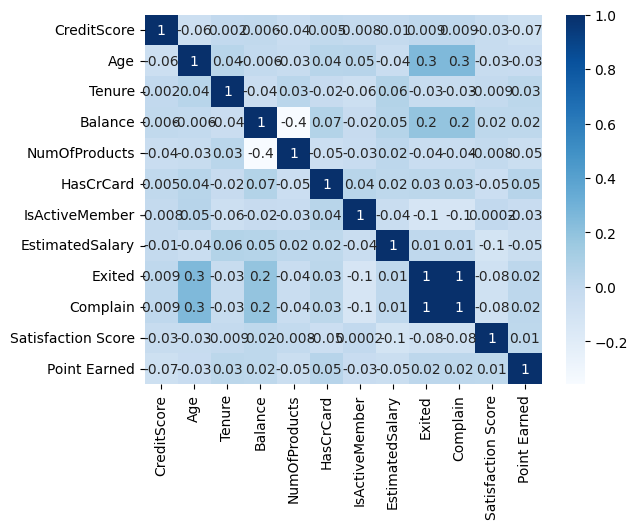

In [ ]:
#correlation heat map
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".01g")


  there is an absolute correlation between the Complain variables and our Target variable, with that we exclude the Complain variable so that we can run our models,

In [ ]:
df = df.drop('Complain', axis = 1)

#Exploratory visual

<Axes: xlabel='Point Earned', ylabel='Count'>

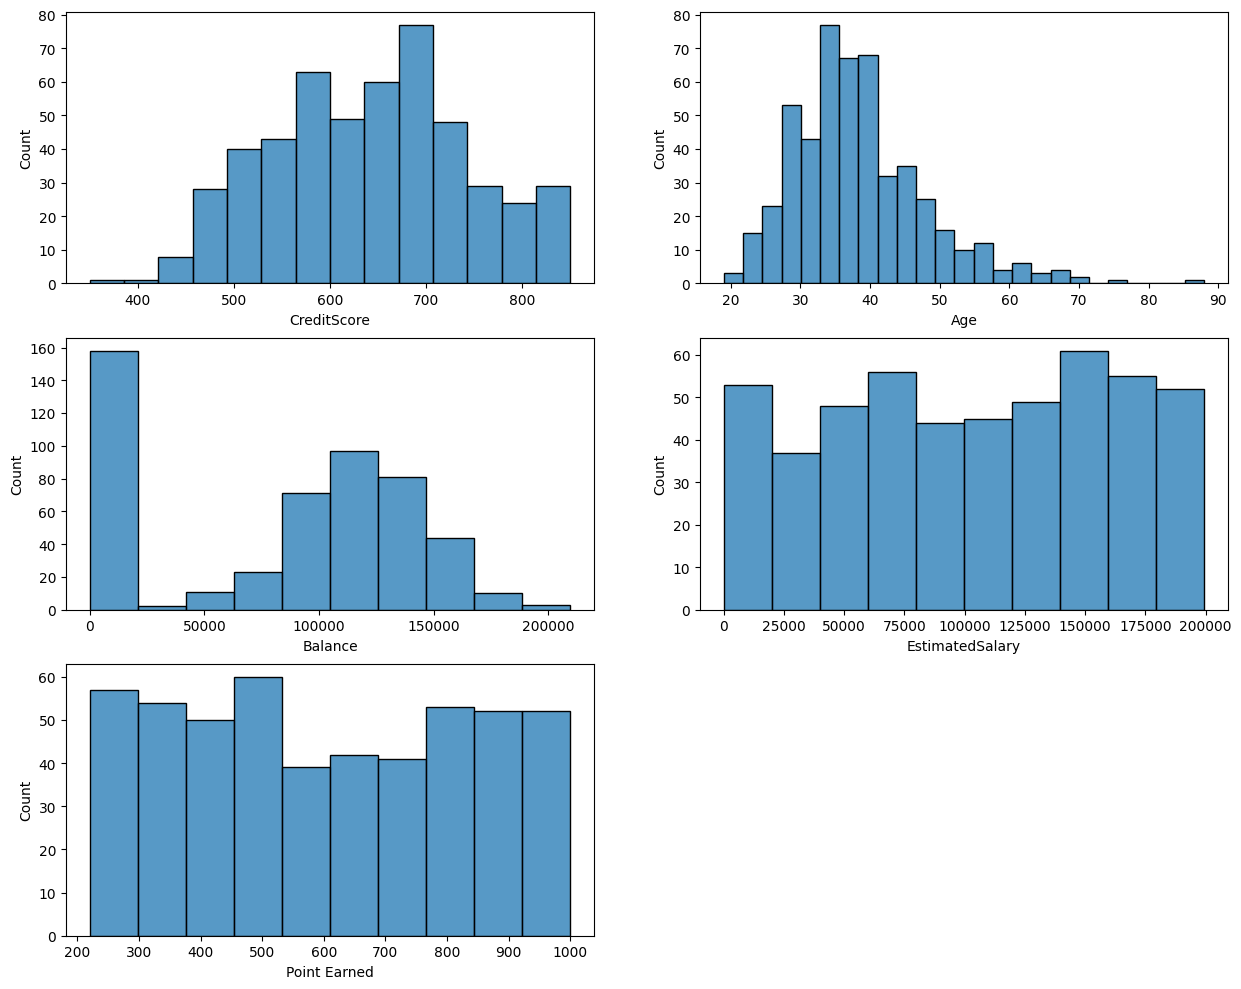

In [ ]:
plt.figure(figsize = (15, 12))

plt.subplot(3, 2, 1)
sns.histplot(x = df['CreditScore'], kde = False)

plt.subplot(3, 2, 2)
sns.histplot(x = df['Age'], kde = False)

plt.subplot(3, 2, 3)
sns.histplot(x = df['Balance'], kde = False)

plt.subplot(3, 2, 4)
sns.histplot(x = df['EstimatedSalary'], kde = False)

plt.subplot(3, 2, 5)
sns.histplot(x = df['Point Earned'], kde = False)

<Axes: title={'center': 'Variable Card Type'}, xlabel='Card Type', ylabel='count'>

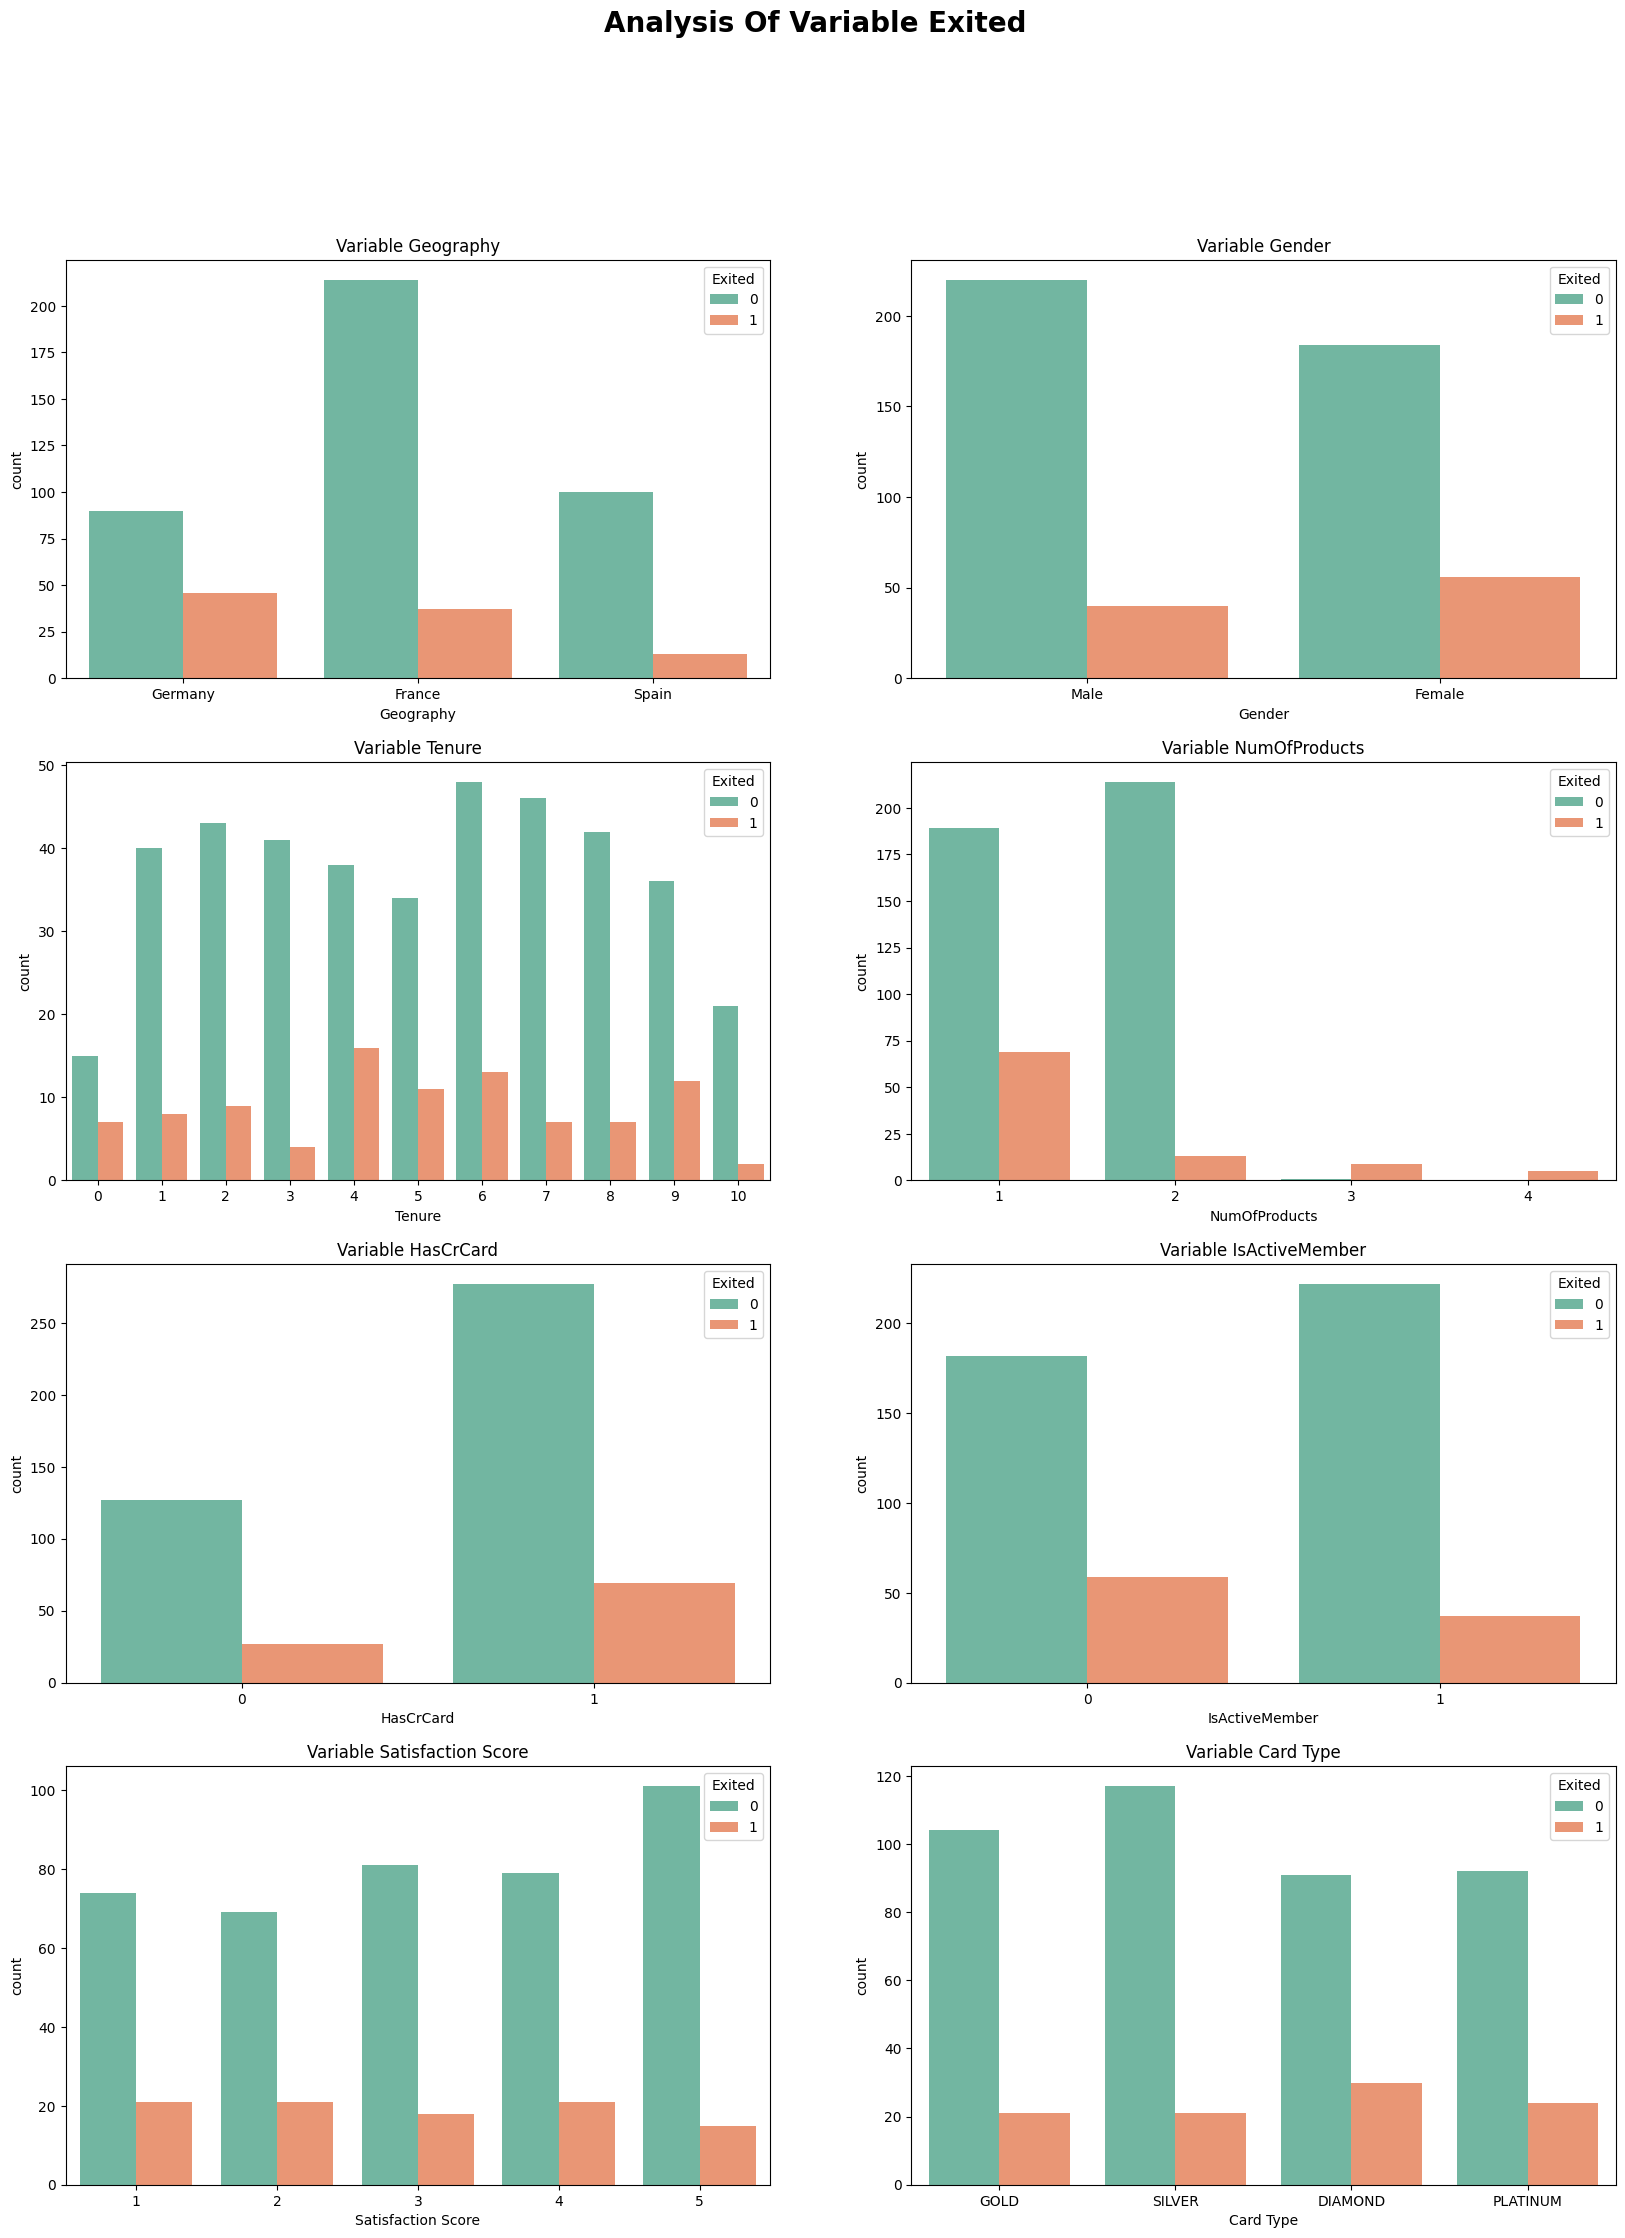

In [ ]:
plt.figure(figsize = (20, 25))
plt.suptitle("Analysis Of Variable Exited",fontweight="bold", fontsize=20)

plt.subplot(4, 2, 1)
plt.gca().set_title('Variable Geography')
sns.countplot(x = 'Geography', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 2)
plt.gca().set_title('Variable Gender')
sns.countplot(x = 'Gender', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 3)
plt.gca().set_title('Variable Tenure')
sns.countplot(x = 'Tenure', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 4)
plt.gca().set_title('Variable NumOfProducts')
sns.countplot(x = 'NumOfProducts', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 5)
plt.gca().set_title('Variable HasCrCard')
sns.countplot(x = 'HasCrCard', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 6)
plt.gca().set_title('Variable IsActiveMember')
sns.countplot(x = 'IsActiveMember', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 7)
plt.gca().set_title('Variable Satisfaction Score')
sns.countplot(x = 'Satisfaction Score', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 8)
plt.gca().set_title('Variable Card Type')
sns.countplot(x = 'Card Type', hue = 'Exited', palette = 'Set2', data = df)

 # Model building

One Hot Encoder
Here we are going to use the OneHotLabel Encoder to transform our categorical variables into continuous variables

In [ ]:
hot = pd.get_dummies(df[['Geography', 'Gender', 'Card Type']])


In [ ]:
 hot.head()

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
6252,0,1,0,0,1,0,1,0,0
4684,1,0,0,0,1,0,0,0,1
1731,0,0,1,1,0,0,1,0,0
4742,0,1,0,0,1,0,0,0,1
4521,0,0,1,1,0,0,0,0,1


In [ ]:
df = pd.concat([df, hot], axis = 1)
df = df.drop(['Geography', 'Gender', 'Card Type'], axis = 1)

Seperating train and testing features

In [ ]:
x=df.drop(['Exited'],axis=1)
y=df['Exited']
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler##Here we will use StandardScaler to put our data in the same scale.
scaler = StandardScaler()
X_standard = scaler.fit_transform(x)

Balancing Classes¶
As we have many values ​​of a class and few values ​​of others, we will balance the classes using OverSampling to make the classes balanced.

Transforming Data into Train e Test, here we will use 30% of our data to test the machine learning models.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X_standard, y, test_size = 0.3, random_state = 0)

#Naive Bayes
Running Gaussian Model.¶
Here we will use the Naive Bayes Model, we will test Gaussian model, using our Normal Data.

In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
# Initialize the Gaussian Naive Bayes classifier
clf = GaussianNB()

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy1 = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy1)

# Generate classification report
report = confusion_matrix(y_test, y_pred)
report

Accuracy: 0.7


array([[89, 35],
       [10, 16]])

Generating classification report

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80       124
           1       0.31      0.62      0.42        26

    accuracy                           0.70       150
   macro avg       0.61      0.67      0.61       150
weighted avg       0.80      0.70      0.73       150



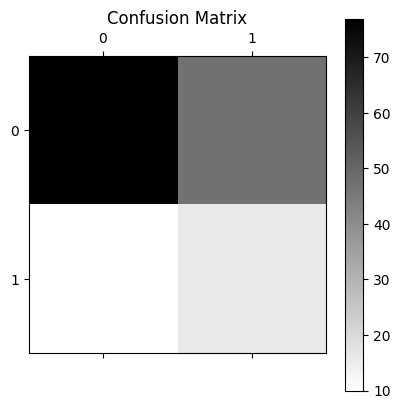

In [ ]:
# Visualize confusion matrix using seaborn heatmap
plt.matshow(conf_matrix, cmap='binary')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()

#Decision Tree Classifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Initialize the Decision Tree classifier
clf = DecisionTreeClassifier()

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy2 = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy2)


Accuracy: 0.7933333333333333


In [ ]:

# Generate classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88       124
           1       0.39      0.35      0.37        26

    accuracy                           0.79       150
   macro avg       0.63      0.62      0.62       150
weighted avg       0.78      0.79      0.79       150



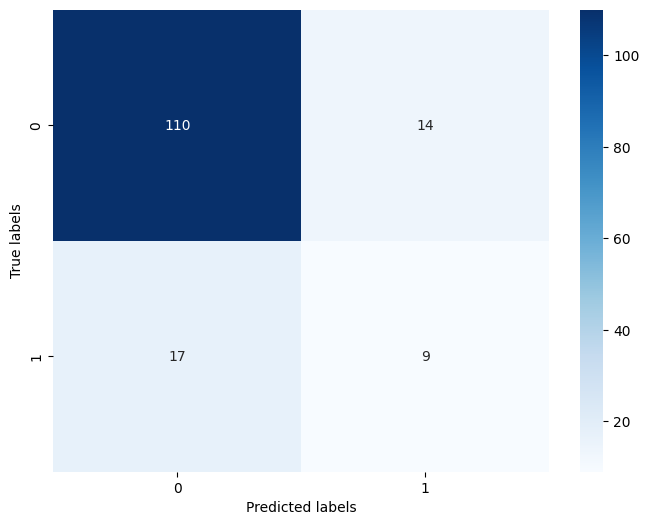

In [ ]:

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# SVM (Support Vector Machine)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Initialize the SVM classifier
clf = SVC(kernel='linear')

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy3 = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy3)

Accuracy: 0.62


In [ ]:
# Generate classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.62      0.73       124
           1       0.25      0.62      0.36        26

    accuracy                           0.62       150
   macro avg       0.57      0.62      0.54       150
weighted avg       0.78      0.62      0.67       150



In [ ]:
conf_matrix=confusion_matrix(y_test, y_pred)
conf_matrix

array([[77, 47],
       [10, 16]])

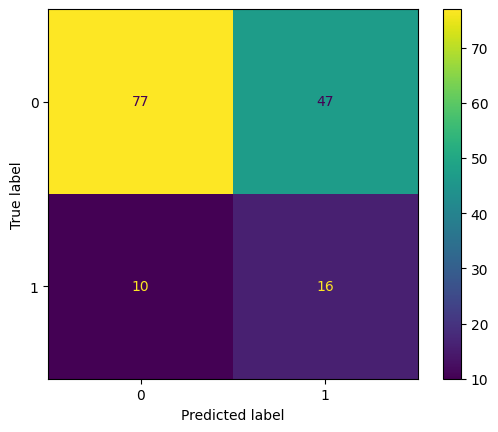

In [ ]:
ConfusionMatrixDisplay(conf_matrix).plot()

In [ ]:
Naive_dict = {'Model':'Naive Bayes',
               'Type':'Gaussian',
               'Precision': accuracy1}

Decision_dict = {'Model':'Decision Tree',
                 'Type':'Gini',
                 'Precision': accuracy2}
SVM_dict =  {'Model':'SVM',
            'Type':'linear',
            'Precision':accuracy3}
resume = pd.DataFrame({'Naive Bayes':pd.Series(Naive_dict),
                       'Decision Tree':pd.Series(Decision_dict),
                       'SVM':pd.Series(SVM_dict)})
resume

,Naive Bayes,Decision Tree,SVM
Model,Naive Bayes,Decision Tree,SVM
Type,Gaussian,Gini,linear
Precision,0.7,0.793333,0.62


# Conclusion

I imported all the necesary libraries and the dataset.I checked quality of the data by various data analysis functions also then data exporatory visualization using matplot n seaborn.I removed some variables that do not make sense for our models, we transformed our Categorical variables into Continuous variables using the OneHot Label Encoder, I separated our data into training with 70% of our data and testing with 30% .
After balancing our Target class and running the Machine Learning models we got some good results and some not so much,in terms of accuracy, the best model was Decision tree with 0.773333 or 77.33%.